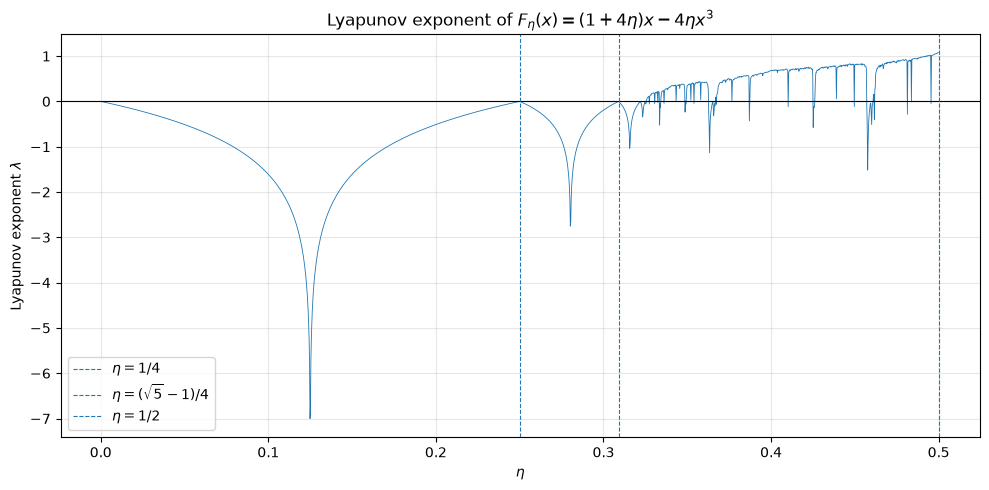

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def F(x, eta):
    """Gradient descent map for f(x) = (x^2 - 1)^2."""
    return (1 + 4 * eta) * x - 4 * eta * x**3


def dF(x, eta):
    """Derivative of F_eta."""
    return 1 + 4 * eta - 12 * eta * x**2


def lyapunov_exponent(
    eta,
    x0=0.123456789,
    n_burn=2000,
    n_iter=5000,
    escape_radius=1e6,
    eps=1e-300,
):
    """
    Numerically estimate the Lyapunov exponent of F_eta from one initial point.

    If the orbit escapes, return np.nan.
    """
    x = x0

    # Burn-in
    for _ in range(n_burn):
        x = F(x, eta)
        if not np.isfinite(x) or abs(x) > escape_radius:
            return np.nan

    # Lyapunov average
    s = 0.0
    for _ in range(n_iter):
        deriv = abs(dF(x, eta))
        s += np.log(max(deriv, eps))

        x = F(x, eta)
        if not np.isfinite(x) or abs(x) > escape_radius:
            return np.nan

    return s / n_iter


# eta range
etas = np.linspace(0.001, 0.8, 3000)

# choose an initial point
x0 = 0.123456789

lambdas = np.array([
    lyapunov_exponent(eta, x0=x0)
    for eta in etas
])

# Important parameter values
eta_period_doubling_1 = 1 / 4
eta_period_doubling_2 = (np.sqrt(5) - 1) / 4
eta_chebyshev = 1 / 2

plt.figure(figsize=(10, 5))
plt.plot(etas, lambdas, lw=0.6)

plt.axhline(0, color="black", lw=0.8)
plt.axvline(eta_period_doubling_1, linestyle="--", lw=0.8, label=r"$\eta=1/4$")
plt.axvline(eta_period_doubling_2, linestyle="--", lw=0.8, label=r"$\eta=(\sqrt{5}-1)/4$")
plt.axvline(eta_chebyshev, linestyle="--", lw=0.8, label=r"$\eta=1/2$")

plt.xlabel(r"$\eta$")
plt.ylabel(r"Lyapunov exponent $\lambda$")
plt.title(r"Lyapunov exponent of $F_\eta(x)=(1+4\eta)x-4\eta x^3$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()